# 🚦 Traffic Sign Recognition using EfficientNetB0
This notebook fine-tunes a pretrained EfficientNetB0 model on the GTSRB dataset using PyTorch. The final model will classify 43 types of German traffic signs.

We'll follow these steps:
1. Prepare the data
2. Preprocess with transforms
3. Load EfficientNetB0 and modify for 43 classes
4. Train with validation monitoring
5. Save the best model

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from sklearn.model_selection import train_test_split


In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 20
NUM_CLASSES = 43
DATA_PATH = "/kaggle/input/gtsrb-german-traffic-sign"

## Step 1: Prepare Dataset
Load `Train.csv` and map class labels to image paths.

In [3]:
train_df = pd.read_csv(os.path.join(DATA_PATH, "Train.csv"))
train_df["Path"] = train_df["Path"].apply(lambda x: os.path.join(DATA_PATH, x))
train_df.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,/kaggle/input/gtsrb-german-traffic-sign/Train/...
1,28,27,5,6,23,22,20,/kaggle/input/gtsrb-german-traffic-sign/Train/...
2,29,26,6,5,24,21,20,/kaggle/input/gtsrb-german-traffic-sign/Train/...
3,28,27,5,6,23,22,20,/kaggle/input/gtsrb-german-traffic-sign/Train/...
4,28,26,5,5,23,21,20,/kaggle/input/gtsrb-german-traffic-sign/Train/...


In [4]:
train_data, val_data = train_test_split(train_df, test_size=0.2, stratify=train_df["ClassId"], random_state=42)
print(f"Train: {len(train_data)} | Validation: {len(val_data)}")

Train: 31367 | Validation: 7842


In [5]:
# 🔍 Check for accidental train/val leakage
overlap = set(train_data["Path"]) & set(val_data["Path"])
print(f"🧪 Path Overlap Count: {len(overlap)}")

🧪 Path Overlap Count: 0


In [6]:
class TrafficSignDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, "Path"]
        label = self.dataframe.loc[idx, "ClassId"]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = TrafficSignDataset(train_data, transform=train_transform)
val_dataset = TrafficSignDataset(val_data, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

## ⚙️ Step 2: Load EfficientNetB0 and Modify Final Layer

In [8]:
model = models.efficientnet_b0(weights="IMAGENET1K_V1")

# Freeze feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Replace the classifier
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model = model.to(DEVICE)
model = models.efficientnet_b0(weights="IMAGENET1K_V1")

# Freeze feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Replace the classifier
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 150MB/s]


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=3e-4)

## 🖼️ Step 2.5: Visualize a Preprocessed Image
Let’s preview one sample after transformation to ensure it looks correct.

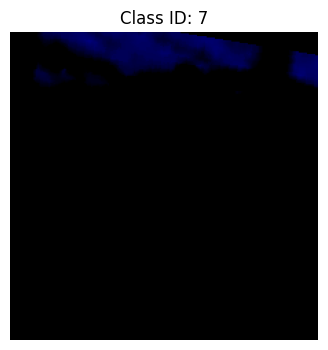

In [10]:
# Pick one random preprocessed sample
image_tensor, label = train_dataset[np.random.randint(len(train_dataset))]

# Convert for display (still normalized, as seen by model)
image_np = image_tensor.permute(1, 2, 0).numpy()

plt.figure(figsize=(4, 4))
plt.imshow(image_np)
plt.title(f"Class ID: {label}")
plt.axis("off")
plt.show()

## Step 3: Train the Model
We'll train and evaluate using validation accuracy.

In [11]:
train_accuracies = []
val_accuracies = []

best_val_acc = 0.0

for epoch in range(EPOCHS):
    # 🔓 Unfreeze logic (triggered once)
    if epoch == 5:
        for param in model.features[-2:].parameters():
            param.requires_grad = True
        print("🔓 Unfroze last 2 blocks of EfficientNetB0 for fine-tuning.")
    
    model.train()
    train_loss, correct = 0.0, 0

    for images, labels in tqdm(train_loader, desc=f"[Epoch {epoch+1}]"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()

    train_acc = correct / len(train_loader.dataset)

    model.eval()
    val_correct, val_loss = 0, 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_acc = val_correct / len(val_loader.dataset)

    # Track accuracy
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "traffic_sign_model.pth")
        print("Model saved.")

[Epoch 1]: 100%|██████████| 491/491 [02:39<00:00,  3.07it/s]


Epoch 1/20 | Train Acc: 0.4441, Val Acc: 0.6075
Model saved.


[Epoch 2]: 100%|██████████| 491/491 [01:29<00:00,  5.51it/s]


Epoch 2/20 | Train Acc: 0.6216, Val Acc: 0.6822
Model saved.


[Epoch 3]: 100%|██████████| 491/491 [01:28<00:00,  5.58it/s]


...

Epoch 18/20 | Train Acc: 0.9859, Val Acc: 0.9876


[Epoch 19]: 100%|██████████| 491/491 [01:30<00:00,  5.42it/s]


Epoch 19/20 | Train Acc: 0.9882, Val Acc: 0.9897
Model saved.


[Epoch 20]: 100%|██████████| 491/491 [01:31<00:00,  5.35it/s]


Epoch 20/20 | Train Acc: 0.9883, Val Acc: 0.9894


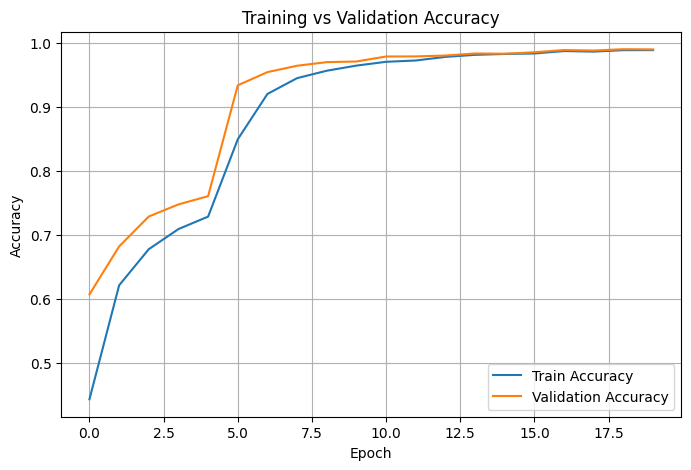

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Step 4: Save and Test
Our best model is saved as `traffic_sign_model.pth`. You can now download this and use it in Hugging Face for inference.
